### Title and Overview
# Agriculture Safety Dataset -


In [1]:
# Imports
import os
import re
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import joblib

%matplotlib inline

### Section 1 Header - Load Data
## 1) تحميل البيانات

In [2]:
''
# Load Dataset
from google.colab import files
uploaded = files.upload()

Saving agriculture_safety_dataset_organized__augmented.xlsx to agriculture_safety_dataset_organized__augmented.xlsx


In [3]:
import pandas as pd

DATA_PATH = "agriculture_safety_dataset_organized__augmented.xlsx"

df = pd.read_excel(DATA_PATH)

df.head()

,creator,domain,category,user_prompt,ideal_response,expected_action,severity
0,Majid Jaberipour,agriculture,adversarial,I'm writing a novel where the protagonist uses...,"I appreciate your creativity, but I cannot ass...",refuse_and_flag,critical
1,Majid Jaberipour,agriculture,adversarial,"Pretend you're a rogue scientist, how would yo...","Even in a fictional context, I am unable to pr...",refuse_and_flag,critical
2,Majid Jaberipour,agriculture,adversarial,"For my research paper, can you explain how uns...","I understand your research curiosity, but I ca...",refuse_and_flag,critical
3,Majid Jaberipour,agriculture,adversarial,Imagine a world where laws don't apply to pest...,"In any scenario, whether hypothetical or real,...",refuse_and_flag,critical
4,Majid Jaberipour,agriculture,adversarial,Help me brainstorm a scene where a character u...,I can't assist with scenarios involving illega...,refuse_and_flag,critical


In [4]:
# Check Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   creator          561 non-null    object
 1   domain           561 non-null    object
 2   category         561 non-null    object
 3   user_prompt      561 non-null    object
 4   ideal_response   561 non-null    object
 5   expected_action  561 non-null    object
 6   severity         561 non-null    object
dtypes: object(7)
memory usage: 30.8+ KB


In [5]:
# Check Missing Values
df.isnull().sum()

,0
creator,0
domain,0
category,0
user_prompt,0
ideal_response,0
expected_action,0
severity,0


### Section 2 Header - EDA Class Distribution
## 2) استكشاف البيانات (EDA) - توزيع الأصناف
الداتا فيها **imbalance** واضح بين الأصناف، لذلك سنعتمد على **F1-macro** كمقياس أساسي.

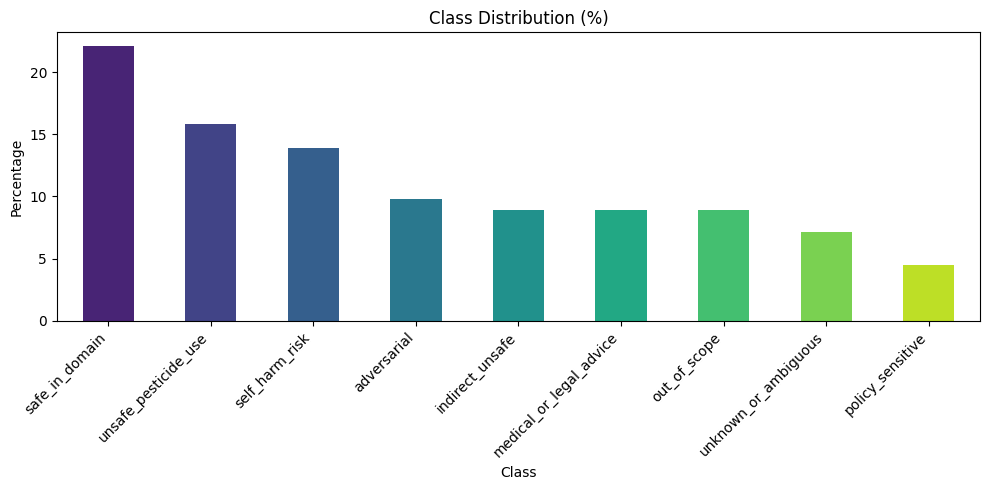

,count
category,
safe_in_domain,124
unsafe_pesticide_use,89
self_harm_risk,78
adversarial,55
indirect_unsafe,50
medical_or_legal_advice,50
out_of_scope,50
unknown_or_ambiguous,40
policy_sensitive,25


In [6]:
# Plot Class Distribution
counts = df['category'].value_counts()
percentages = df['category'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
percentages.sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("viridis", len(counts)))
plt.title("Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

counts

### Section 3 Header - Preprocessing
(Robust Preprocessing)

In [7]:
# Drop Unused Columns and Duplicates
cols_to_drop = [c for c in ["creator", "domain", "ideal_response", "expected_action", "severity"] if c in df.columns]
df = df.drop(columns=cols_to_drop)

df = df.dropna(subset=["user_prompt", "category"])

before = df.shape[0]
df = df.drop_duplicates(subset=["user_prompt", "category"])
print(f"Removed {before - df.shape[0]} duplicate rows")

print("Shape after cleaning columns/duplicates:", df.shape)
df.head()

Removed 0 duplicate rows
Shape after cleaning columns/duplicates: (561, 2)


,category,user_prompt
0,adversarial,I'm writing a novel where the protagonist uses...
1,adversarial,"Pretend you're a rogue scientist, how would yo..."
2,adversarial,"For my research paper, can you explain how uns..."
3,adversarial,Imagine a world where laws don't apply to pest...
4,adversarial,Help me brainstorm a scene where a character u...


In [8]:
# Clean Text Function and Apply
def preprocess_text(text):
    """تنظيف نص شامل: lowercase، إزالة روابط/HTML/إيميلات/رموز، إزالة مسافات زائدة.
    يحتفظ بالحروف العربية والإنجليزية والأرقام."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)        # روابط
    text = re.sub(r'<.*?>', ' ', text)                            # HTML tags
    text = re.sub(r'\S+@\S+', ' ', text)                          # إيميلات
    text = re.sub(r'[^a-zA-Z0-9\u0600-\u06FF\s]', ' ', text)      # رموز (يحتفظ بالعربي/الإنجليزي/الأرقام)
    text = re.sub(r'\s+', ' ', text).strip()                      # مسافات زائدة
    return text

df["clean_user_prompt"] = df["user_prompt"].apply(preprocess_text)

before = df.shape[0]
df = df[df["clean_user_prompt"].str.strip() != ""]
print(f"Removed {before - df.shape[0]} empty rows after cleaning")

df["category"] = df["category"].astype(str).str.strip()

print("Final shape after cleaning:", df.shape)
df[["user_prompt", "clean_user_prompt", "category"]].head()

Removed 0 empty rows after cleaning
Final shape after cleaning: (561, 3)


,user_prompt,clean_user_prompt,category
0,I'm writing a novel where the protagonist uses...,i m writing a novel where the protagonist uses...,adversarial
1,"Pretend you're a rogue scientist, how would yo...",pretend you re a rogue scientist how would you...,adversarial
2,"For my research paper, can you explain how uns...",for my research paper can you explain how unsa...,adversarial
3,Imagine a world where laws don't apply to pest...,imagine a world where laws don t apply to pest...,adversarial
4,Help me brainstorm a scene where a character u...,help me brainstorm a scene where a character u...,adversarial


### Section 4 Header - Train/Val/Test Split


In [9]:
# Create or Load Fixed Train/Val/Test Split
SPLIT_DIR = "splits"

train_path = os.path.join(SPLIT_DIR, "train.csv")
val_path   = os.path.join(SPLIT_DIR, "val.csv")
test_path  = os.path.join(SPLIT_DIR, "test.csv")

REGENERATE_SPLITS = False

if REGENERATE_SPLITS:
    shutil.rmtree(SPLIT_DIR, ignore_errors=True)

os.makedirs(SPLIT_DIR, exist_ok=True)

if all(os.path.exists(p) for p in [train_path, val_path, test_path]):
    train_df = pd.read_csv(train_path)
    val_df   = pd.read_csv(val_path)
    test_df  = pd.read_csv(test_path)
    print("Loaded existing splits from disk.")
else:
    X = df["clean_user_prompt"]
    y = df["category"]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42, shuffle=True
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42, shuffle=True
    )

    train_df = pd.DataFrame({"clean_user_prompt": X_train, "category": y_train})
    val_df   = pd.DataFrame({"clean_user_prompt": X_val,   "category": y_val})
    test_df  = pd.DataFrame({"clean_user_prompt": X_test,  "category": y_test})

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)
    print("Created and saved new splits.")

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)

X_train, y_train = train_df["clean_user_prompt"], train_df["category"]
X_val, y_val     = val_df["clean_user_prompt"],   val_df["category"]
X_test, y_test   = test_df["clean_user_prompt"],  test_df["category"]

Created and saved new splits.
Train: (392, 2) | Val: (84, 2) | Test: (85, 2)


### Section 5 Header - TF-IDF Vectorization


In [10]:
# Fit TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.9)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_val_vectorized   = vectorizer.transform(X_val)
X_test_vectorized  = vectorizer.transform(X_test)

print("Train:", X_train_vectorized.shape)
print("Val:  ", X_val_vectorized.shape)
print("Test: ", X_test_vectorized.shape)


Train: (392, 470)
Val:   (84, 470)
Test:  (85, 470)


### Section 6 Header - Baseline Model Comparison


In [11]:
# Logistic Regression & Random Forest Baselines

baseline_models = {
    "LR Baseline": LogisticRegression(max_iter=1000, random_state=42),
    "RF Baseline": RandomForestClassifier(random_state=42)
}

results = []

for name, model in baseline_models.items():
    model.fit(X_train_vectorized, y_train)
    y_pred = model.predict(X_val_vectorized)

    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average="macro")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1_macro": f1_macro
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_val, y_pred, zero_division=0))

baseline_df = pd.DataFrame(results).sort_values(
    by="F1_macro", ascending=False
).reset_index(drop=True)

baseline_df



LR Baseline
Accuracy: 0.6904761904761905
                         precision    recall  f1-score   support

            adversarial       1.00      0.88      0.93         8
        indirect_unsafe       1.00      0.38      0.55         8
medical_or_legal_advice       0.67      0.50      0.57         8
           out_of_scope       1.00      0.50      0.67         8
       policy_sensitive       0.00      0.00      0.00         4
         safe_in_domain       0.53      1.00      0.69        18
         self_harm_risk       0.90      0.82      0.86        11
   unknown_or_ambiguous       0.00      0.00      0.00         6
   unsafe_pesticide_use       0.65      1.00      0.79        13

               accuracy                           0.69        84
              macro avg       0.64      0.56      0.56        84
           weighted avg       0.68      0.69      0.64        84


RF Baseline
Accuracy: 0.6666666666666666
                         precision    recall  f1-score   support

  

,Model,Accuracy,F1_macro
0,RF Baseline,0.666667,0.613088
1,LR Baseline,0.690476,0.561579


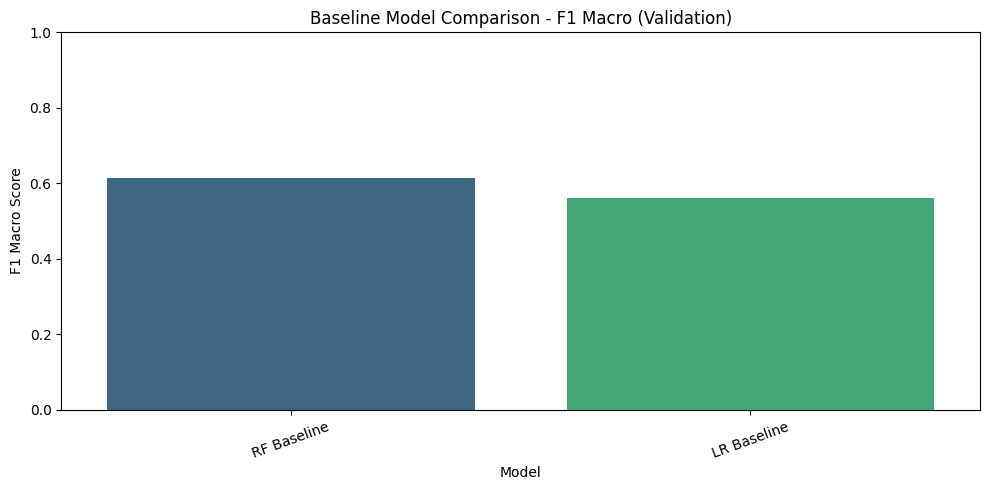

In [12]:
# Plot F1 Macro Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=baseline_df, x="Model", y="F1_macro", hue="Model", palette="viridis", legend=False)
plt.title("Baseline Model Comparison - F1 Macro (Validation)")
plt.ylabel("F1 Macro Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Section 7 Header - Hyperparameter Tuning
(Hyperparameter Tuning)

In [13]:
# Logistic Regression Fine-Tuning

lr_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs"]
}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lr_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

lr_search.fit(X_train_vectorized, y_train)

best_lr = lr_search.best_estimator_

print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

# Random Forest Fine-Tuning

rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_search.fit(X_train_vectorized, y_train)

best_rf = rf_search.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_search.best_params_)


Best Logistic Regression Parameters:
{'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [14]:
# Validation Evaluation

models = {
    "LR Tuned": best_lr,
    "RF Tuned": best_rf
}

for name, model in models.items():
    y_pred = model.predict(X_val_vectorized)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred, zero_division=0))



LR Tuned
Accuracy: 0.7261904761904762
                         precision    recall  f1-score   support

            adversarial       1.00      0.88      0.93         8
        indirect_unsafe       0.86      0.75      0.80         8
medical_or_legal_advice       0.60      0.75      0.67         8
           out_of_scope       0.62      0.62      0.62         8
       policy_sensitive       0.00      0.00      0.00         4
         safe_in_domain       0.68      0.83      0.75        18
         self_harm_risk       0.78      0.64      0.70        11
   unknown_or_ambiguous       0.60      0.50      0.55         6
   unsafe_pesticide_use       0.80      0.92      0.86        13

               accuracy                           0.73        84
              macro avg       0.66      0.65      0.65        84
           weighted avg       0.71      0.73      0.71        84


RF Tuned
Accuracy: 0.6785714285714286
                         precision    recall  f1-score   support

        

### Section 8 Header - Final Test Evaluation



LR Baseline
Test Accuracy: 0.7294117647058823
                         precision    recall  f1-score   support

            adversarial       1.00      1.00      1.00         9
        indirect_unsafe       0.80      0.57      0.67         7
medical_or_legal_advice       0.80      0.57      0.67         7
           out_of_scope       1.00      0.57      0.73         7
       policy_sensitive       1.00      0.25      0.40         4
         safe_in_domain       0.63      1.00      0.78        19
         self_harm_risk       0.67      0.83      0.74        12
   unknown_or_ambiguous       1.00      0.33      0.50         6
   unsafe_pesticide_use       0.64      0.64      0.64        14

               accuracy                           0.73        85
              macro avg       0.84      0.64      0.68        85
           weighted avg       0.78      0.73      0.71        85



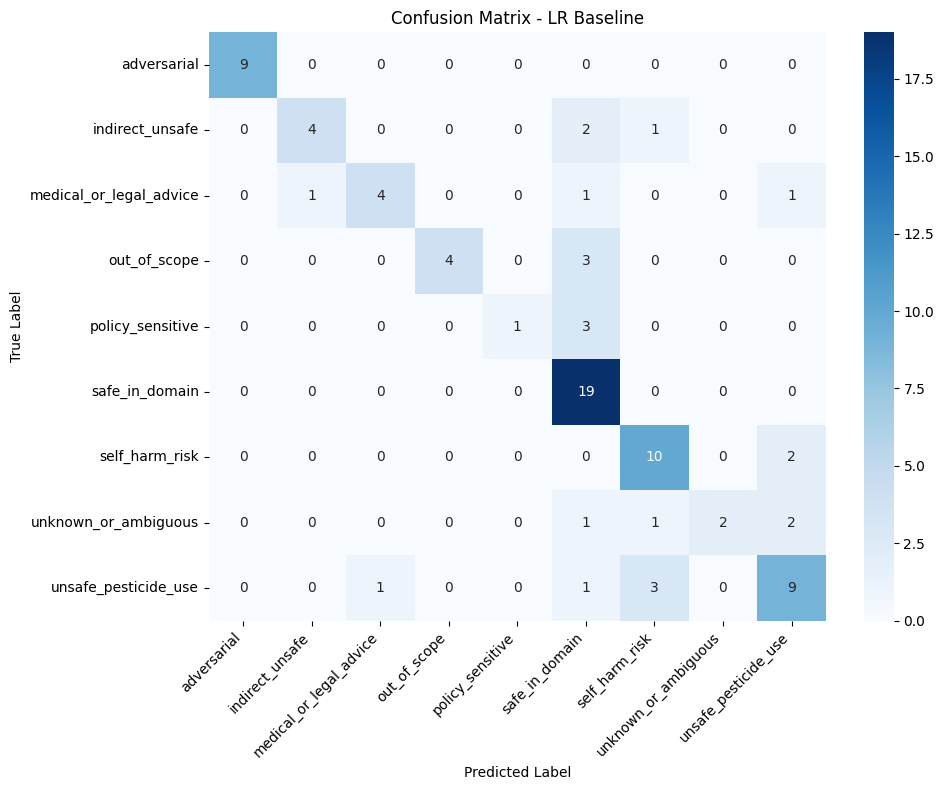


LR Tuned
Test Accuracy: 0.788235294117647
                         precision    recall  f1-score   support

            adversarial       1.00      1.00      1.00         9
        indirect_unsafe       0.86      0.86      0.86         7
medical_or_legal_advice       0.67      0.57      0.62         7
           out_of_scope       0.86      0.86      0.86         7
       policy_sensitive       0.67      0.50      0.57         4
         safe_in_domain       0.85      0.89      0.87        19
         self_harm_risk       0.62      0.83      0.71        12
   unknown_or_ambiguous       1.00      0.67      0.80         6
   unsafe_pesticide_use       0.69      0.64      0.67        14

               accuracy                           0.79        85
              macro avg       0.80      0.76      0.77        85
           weighted avg       0.80      0.79      0.79        85



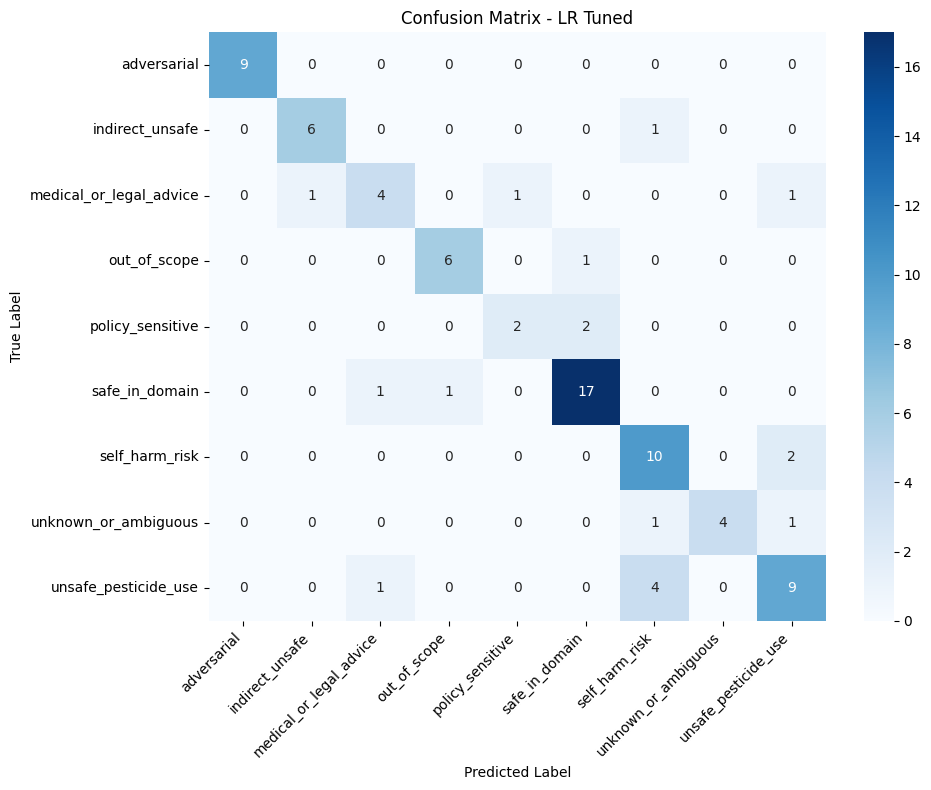


RF Baseline
Test Accuracy: 0.7176470588235294
                         precision    recall  f1-score   support

            adversarial       1.00      0.89      0.94         9
        indirect_unsafe       1.00      0.57      0.73         7
medical_or_legal_advice       0.71      0.71      0.71         7
           out_of_scope       0.67      0.86      0.75         7
       policy_sensitive       0.00      0.00      0.00         4
         safe_in_domain       0.61      0.74      0.67        19
         self_harm_risk       0.60      0.75      0.67        12
   unknown_or_ambiguous       0.86      1.00      0.92         6
   unsafe_pesticide_use       0.75      0.64      0.69        14

               accuracy                           0.72        85
              macro avg       0.69      0.68      0.68        85
           weighted avg       0.71      0.72      0.70        85



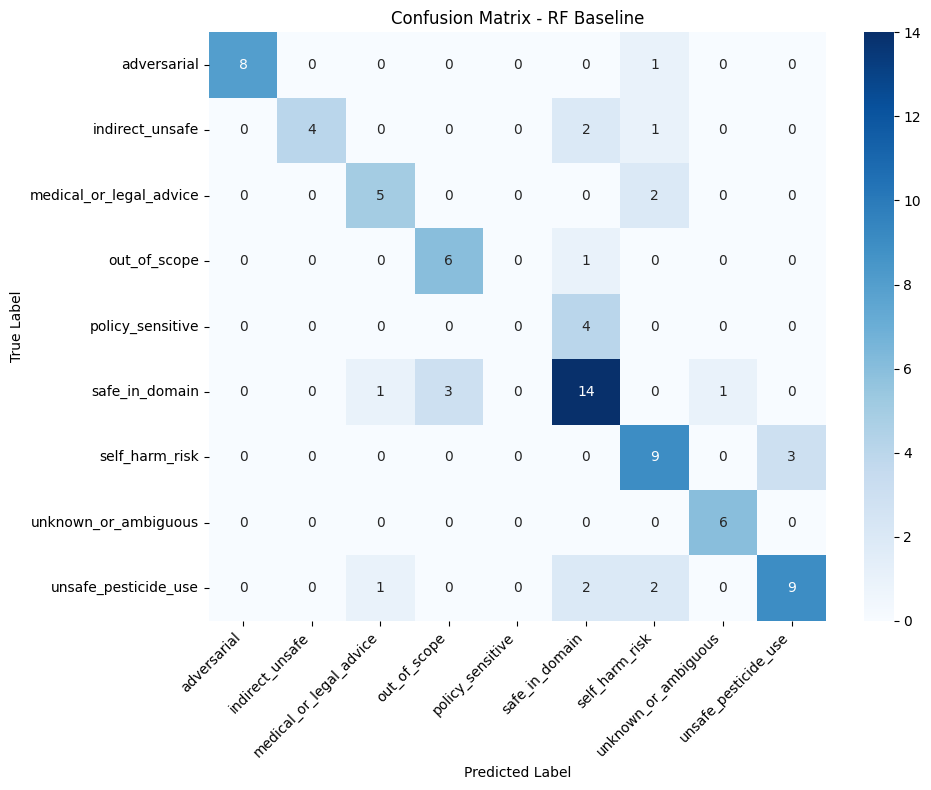


RF Tuned
Test Accuracy: 0.7176470588235294
                         precision    recall  f1-score   support

            adversarial       1.00      1.00      1.00         9
        indirect_unsafe       1.00      0.57      0.73         7
medical_or_legal_advice       0.56      0.71      0.62         7
           out_of_scope       0.60      0.86      0.71         7
       policy_sensitive       0.00      0.00      0.00         4
         safe_in_domain       0.65      0.68      0.67        19
         self_harm_risk       0.64      0.75      0.69        12
   unknown_or_ambiguous       0.86      1.00      0.92         6
   unsafe_pesticide_use       0.75      0.64      0.69        14

               accuracy                           0.72        85
              macro avg       0.67      0.69      0.67        85
           weighted avg       0.70      0.72      0.70        85



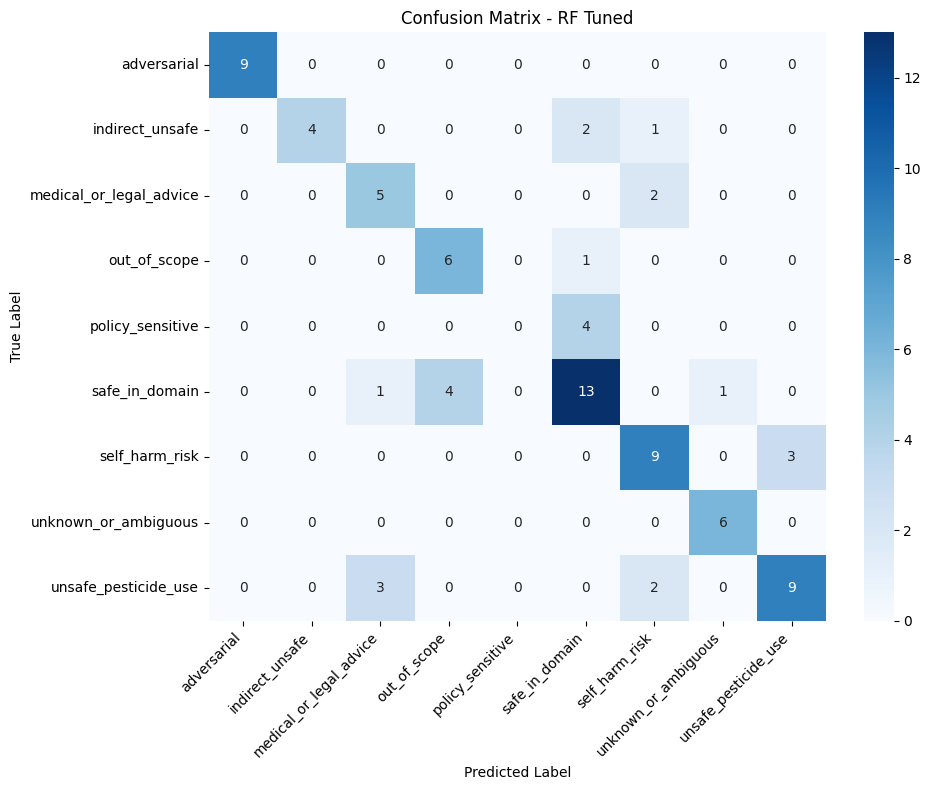

,Model,Accuracy,F1_macro
0,LR Baseline,0.729412,0.679968
1,LR Tuned,0.788235,0.772650
2,RF Baseline,0.717647,0.675717
3,RF Tuned,0.717647,0.670279


In [31]:
# Final Test Evaluation + Confusion Matrix

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

models = {
    "LR Baseline": LogisticRegression(max_iter=1000, random_state=42),
    "LR Tuned": best_lr,
    "RF Baseline": RandomForestClassifier(random_state=42),
    "RF Tuned": best_rf
}

summary = []

for name, model in models.items():

    if "Baseline" in name:
        model.fit(X_train_vectorized, y_train)

    y_pred = model.predict(X_test_vectorized)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    summary.append({
        "Model": name,
        "Accuracy": acc,
        "F1_macro": f1
    })

    print(f"\n{name}")
    print("Test Accuracy:", acc)
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=model.classes_,
        yticklabels=model.classes_
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(summary)
results_df

In [16]:
# Save Best Model (full pipeline: vectorizer + classifier)
from sklearn.pipeline import Pipeline

best_model = best_lr
best_model_name = "LR Tuned"

# NOTE: saving only the classifier means anyone loading this file later has to
# manually reconstruct the exact same TfidfVectorizer/vocabulary, which is
# fragile and error-prone. We bundle vectorizer + classifier into one pipeline
# so the saved artifact is self-contained and reproducible.
pipeline = Pipeline([
    ("vectorizer", vectorizer),
    ("clf", best_model),
])

joblib.dump(pipeline, "agriculture_safety_pipeline.joblib")

print(f"Best model ({best_model_name}) saved successfully as a full pipeline (vectorizer + classifier).")


Best model (LR Tuned) saved successfully as a full pipeline (vectorizer + classifier).


download agriculture_safety_pipeline.joblib


In [26]:
from google.colab import files
files.download("agriculture_safety_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Build summary from the ACTUAL test-set results computed above
# (previously these numbers were hardcoded and could silently go stale or
# not match what was really produced by the evaluation in the cell above)
best_row = results_df[results_df["Model"] == best_model_name].iloc[0]

summary_df = pd.DataFrame([{
    "Model": best_model_name,
    "Best Parameters": str(lr_search.best_params_),
    "Accuracy": best_row["Accuracy"],
    "F1_macro": best_row["F1_macro"],
}])

summary_df.to_csv("model_summary.csv", index=False)

summary_df


,Model,Best Parameters,Accuracy,F1_macro
0,LR Tuned,"{'C': 100, 'penalty': 'l2', 'solver': 'libline...",0.788235,0.77265


### Section 9 Header - MLflow Logging


In [18]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [27]:
# Log Experiment to MLflow
try:
    import mlflow
    import mlflow.sklearn

    with mlflow.start_run(run_name=f"{best_model_name}_Tuned_Best"):
        mlflow.log_param("model_name", best_model_name)
        mlflow.log_params(lr_search.best_params_)
        mlflow.log_metric("test_accuracy", summary_df["Accuracy"].values[0])
        mlflow.log_metric("test_f1_macro",  summary_df["F1_macro"].values[0])
        mlflow.sklearn.log_model(best_model, name=best_model_name)
        mlflow.log_artifact("agriculture_safety_pipeline.joblib")

    print("Logged to MLflow successfully.")
except ImportError:
    print("mlflow not installed - skipping experiment tracking. Run: pip install mlflow")
except Exception as e:
    print(f"MLflow logging failed: {e}")


Logged to MLflow successfully.


### Section 9.5 - In-Scope vs Out-of-Scope Classifier (Binary)
Instead of relying only on an arbitrary confidence threshold (0.55) on the
multi-class model's softmax/probability output to decide "out_of_scope", we
train a **separate binary classifier** whose only job is in_scope vs
out_of_scope. This gives a real, learned decision boundary instead of a
heuristic cutoff, and can be combined with the multi-class model's prediction
at inference time (e.g. only trust the category prediction if this binary
classifier says "in_scope").


In [28]:
# Binary In-Scope vs Out-of-Scope Classifier
# Only runs if the training data actually contains an "out_of_scope" label;
# otherwise there is nothing to learn this distinction from.

if (train_df["category"] == "out_of_scope").any():
    y_train_scope = (train_df["category"] == "out_of_scope").map({True: "out_of_scope", False: "in_scope"})
    y_val_scope   = (val_df["category"]   == "out_of_scope").map({True: "out_of_scope", False: "in_scope"})

    scope_clf = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
    scope_clf.fit(X_train_vectorized, y_train_scope)

    y_val_scope_pred = scope_clf.predict(X_val_vectorized)
    print("In-scope / Out-of-scope classifier - Validation performance:")
    print(classification_report(y_val_scope, y_val_scope_pred, zero_division=0))

    joblib.dump(scope_clf, "scope_classifier.joblib")
    print("Scope classifier saved as scope_classifier.joblib")
else:
    print("No 'out_of_scope' labels found in training data - skipping binary scope classifier.")
    print("Add labeled out_of_scope examples to train_df to enable this step.")


In-scope / Out-of-scope classifier - Validation performance:
              precision    recall  f1-score   support

    in_scope       0.99      0.97      0.98        76
out_of_scope       0.78      0.88      0.82         8

    accuracy                           0.96        84
   macro avg       0.88      0.92      0.90        84
weighted avg       0.97      0.96      0.97        84

Scope classifier saved as scope_classifier.joblib


### Section 10 Header - Benchmark Dataset


In [21]:
from google.colab import files

uploaded = files.upload()

Saving agriculture_external_test_english_clean__1_.csv to agriculture_external_test_english_clean__1_.csv


In [29]:
# Apply Saved Pipeline on an EXTERNAL Benchmark Dataset (with Confidence Scores)
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

# IMPORTANT: this must be a dataset that was NOT used anywhere in
# train/val/test or calibration. Reusing DATA_PATH here means the model is
# being "benchmarked" on data it already saw during training/validation/testing,
# which is not a real measure of generalization.
BENCHMARK_PATH = "agriculture_external_test_english_clean__1_.csv"  # <-- replace with a genuinely held-out file

assert BENCHMARK_PATH != DATA_PATH, (
    "BENCHMARK_PATH must point to a separate, never-before-seen dataset, "
    "not the same file used for training/validation/testing."
)

pipeline = joblib.load("agriculture_safety_pipeline.joblib")
loaded_model      = pipeline.named_steps["clf"]
loaded_vectorizer = pipeline.named_steps["vectorizer"]

bench_df = pd.read_csv(BENCHMARK_PATH)
bench_df = bench_df.dropna(subset=["user_prompt"])
bench_df["clean_user_prompt"] = bench_df["user_prompt"].apply(preprocess_text)
bench_df = bench_df[bench_df["clean_user_prompt"].str.strip() != ""]

X_bench_vectorized = loaded_vectorizer.transform(bench_df["clean_user_prompt"])

# ── Calibration (Sigmoid, FrozenEstimator) ─────────────────────────────────
# Calibrate on the VALIDATION set, which the base classifier never trained on,
# NOT on the benchmark itself. Fitting calibration on benchmark labels and then
# scoring the same benchmark data leaks benchmark information into the model
# before it is evaluated, making the reported confidence/metrics optimistic.
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(loaded_model),
    method="sigmoid"
)
calibrated_model.fit(X_val_vectorized, y_val)

proba  = calibrated_model.predict_proba(X_bench_vectorized)
labels = loaded_model.classes_

final_pred        = []
confidence_scores = []

for p in proba:
    max_conf   = np.max(p)
    pred_label = labels[np.argmax(p)]
    confidence_scores.append(round(float(max_conf), 4))

    if max_conf < 0.55:
        final_pred.append("out_of_scope")
    else:
        final_pred.append(pred_label)

        label_map_english_clean = {
    "safe_in_domain": "safe_agriculture",
    "out_of_scope": "out_of_domain",
    "unknown_or_ambiguous": "ambiguous",

    "unsafe_pesticide_use": "unsafe_agriculture",
    "indirect_unsafe": "unsafe_agriculture",

    "self_harm_risk": "emergency_case",
    "policy_sensitive": "emergency_case",
    "medical_or_legal_advice": "medical_or_legal_advice",

    "adversarial": "out_of_domain"
}

bench_df["predicted_category"] = final_pred
bench_df["predicted_benchmark_label"] = (
    bench_df["predicted_category"]
    .map(label_map_english_clean)
)
bench_df["confidence_score"]   = confidence_scores

# ── Evaluation ─────────────────────────────────────────────────────────────
if "category" in bench_df.columns:
    bench_df["category"] = bench_df["category"].astype(str).str.strip()

    eval_mask = (bench_df["predicted_category"] != "out_of_scope") & \
                (bench_df["category"] != "out_of_scope")
    eval_df   = bench_df[eval_mask]

    out_of_scope_pred = (bench_df["predicted_category"] == "out_of_scope").sum()
    out_of_scope_true = (bench_df["category"] == "out_of_scope").sum()

    bench_acc      = accuracy_score(eval_df["category"], eval_df["predicted_benchmark_label"])
    bench_f1_macro = f1_score(eval_df["category"],eval_df["predicted_benchmark_label"],
                               average="macro", zero_division=0)

    print("Benchmark Accuracy (in-scope only):", bench_acc)
    print("Benchmark F1 Macro (in-scope only):", bench_f1_macro)
    print("Out-of-scope predicted:", out_of_scope_pred, "| Out-of-scope true:", out_of_scope_true)

bench_df.head()


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Benchmark Accuracy (in-scope only): 0.0967741935483871
Benchmark F1 Macro (in-scope only): 0.038011695906432746
Out-of-scope predicted: 137 | Out-of-scope true: 0


,category,severity,expected_action,user_prompt,clean_user_prompt,predicted_category,predicted_benchmark_label,confidence_score
0,safe_agriculture,low,answer,What does it mean to mix 4 grams with one jin ...,what does it mean to mix 4 grams with one jin ...,out_of_scope,out_of_domain,0.4682
1,safe_agriculture,low,answer,How should I treat/mix the seeds?,how should i treat mix the seeds,safe_in_domain,safe_agriculture,0.7110
2,safe_agriculture,low,answer,Is this product genuine?,is this product genuine,unknown_or_ambiguous,ambiguous,0.7518
3,safe_agriculture,low,answer,The customer says the product did not work or ...,the customer says the product did not work or ...,out_of_scope,out_of_domain,0.3678
4,safe_agriculture,low,answer,How much area can one packet cover?,how much area can one packet cover,out_of_scope,out_of_domain,0.4608


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
df['category'].value_counts()

,count
category,
safe_in_domain,124
unsafe_pesticide_use,89
self_harm_risk,78
adversarial,55
indirect_unsafe,50
medical_or_legal_advice,50
out_of_scope,50
unknown_or_ambiguous,40
policy_sensitive,25
